In [1]:
#!/usr/bin/env python3
import getopt
import os
import sys
import re
import time
import numpy as np
import datetime as dt
import argparse
import shutil
import daz_lib_licsar as dl
from lics_unwrap import *


setting pyproj data directory


In [3]:
help(dl.get_daz_frame)

Help on function get_daz_frame in module daz_lib_licsar:

get_daz_frame(frame, fulloutput=True, include_corrections=False)
    Function to extract all frame daz values from the LiCSInfo database.
    
    Args:
        frame (str)                 LiCSAR frame ID
        fulloutput (bool)           if True, will return all information from the database, otherwise only daz values [mm]
        include_corrections (bool)  if True, will perform also SET and iono corrections and add to the table (or daz if False fulloutput)



In [2]:
tsadir='/work/scratch-pw2/licsar/mnergiz/new/014A_05232_242525/TS_GEOCml10'
framedir='/work/scratch-pw2/licsar/mnergiz/new/014A_05232_242525'
frame=os.path.basename(framedir)
cumfile=os.path.join(tsadir,'cum.h5')
with h5.File(cumfile, 'r') as f:
    cum = f['cum'][()]
    imdates = f['imdates'][()].astype(str)

cum = cum - cum[0]  # reference to first epoch


In [5]:
# Get daz values
dazes = dl.get_daz_frame(frame)[['epoch', 'daz']]
dazes['epoch'] = pd.to_datetime(dazes['epoch'])
dazes['daz'] = dazes['daz'] * 14000  # convert to mm

In [6]:
dazes

,epoch,daz
0,2022-12-23,62.947640
1,2014-10-06,-139.675340
2,2015-09-19,-76.298040
3,2015-12-24,-55.466600
4,2016-01-05,-98.379680
...,...,...
436,2021-04-08,13.852818
437,2021-04-14,-47.229280
438,2021-04-20,-73.489500
439,2021-04-26,-11.341792


In [7]:
df_daz = pd.DataFrame({'epoch': pd.to_datetime(imdates)})
df_daz = df_daz.merge(dazes, on='epoch', how='left').sort_values('epoch')
df_daz['daz'] = df_daz['daz'].interpolate(method='nearest', limit_direction='both')
daz = df_daz['daz'].to_numpy() - df_daz['daz'].iloc[0]  # align to first epoch


In [10]:
# Apply correction
cum_abs = cum + daz[:, None, None]

In [11]:
cum_abs

array([[[ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        ..., 
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan]],

       [[ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        ..., 
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan]],

       [[ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        ..., 
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan]],

       ..., 
       [[ nan,  nan, 

In [3]:
cum

array([[[ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        ..., 
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan]],

       [[ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        ..., 
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan]],

       [[ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        ..., 
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan]],

       ..., 
       [[ nan,  nan, 

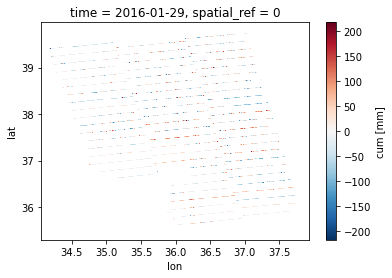

In [75]:
cube.cum[1].plot(x='lon', y='lat')

In [72]:
cube.cum_abs[1].shape

(468, 387)

In [73]:
cube.cum[1].shape

(468, 387)

In [71]:
# --- Set paths ---
tsadir = '/work/scratch-pw2/licsar/mnergiz/new/014A_05232_242525/TS_GEOCml10'
framedir = '/work/scratch-pw2/licsar/mnergiz/new/014A_05232_242525'
frame = os.path.basename(framedir)

# --- Load cumulative time-series cube ---
cumfile = os.path.join(tsadir, 'cum.h5')
cube = loadall2cube(cumfile)

# # --- Reference the cumulative displacement to the first acquisition date ---
# first_date = cube.time.isel(time=0).values.astype(str).split('T')[0]
# cube['cum'] = cube['cum'] - cube['cum'].sel(time=first_date)

# # --- Create DataFrame from cube time steps ---
# df_cube = pd.DataFrame({'epoch': pd.to_datetime(cube['time'].values)})

# # --- Load azimuth ionospheric delay (daz) from frame ---
# dazes = dl.get_daz_frame(frame)[['epoch', 'daz']]
# dazes['epoch'] = pd.to_datetime(dazes['epoch'])
# dazes['daz'] = dazes['daz'] * 14000  # Convert to phase delay

# # --- Merge and interpolate ---
# df_merged = pd.merge(df_cube, dazes, on='epoch', how='left')       # Keep all epochs from cube
# df_merged = df_merged.sort_values(by='epoch')                      # Ensure chronological order
# df_merged['daz'] = df_merged['daz'].interpolate(
#     method='nearest', limit_direction='both')                      # Fill missing daz values



No loop_ph_avg_abs file detected, skipping



In [40]:
df_merged.to_csv('check.csv')
dazes.to_csv('check2.csv')

In [41]:



# Convert merged DataFrame to xarray format
df_merged_xr = df_merged.set_index("epoch").to_xarray()

# Align the daz column with the cube dataset based on the 'time' dimension
cube = cube.assign(
    daz=("time", df_merged_xr.daz.reindex(time=cube["time"], method="nearest").data)
)
# Display the updated cube dataset
cube['daz'] = cube['daz'] - cube['daz'].sel(time=imd_m)
cube['cum_absolute']=cube['cum']+cube['daz']

In [43]:
df_merged_xr

<xarray.Dataset>
Dimensions:  (epoch: 362)
Coordinates:
  * epoch    (epoch) datetime64[ns] 2016-01-05 2016-01-29 ... 2022-12-23
Data variables:
    daz      (epoch) float64 -98.38 -119.6 -80.58 -59.61 ... 0.3358 -7.651 62.95

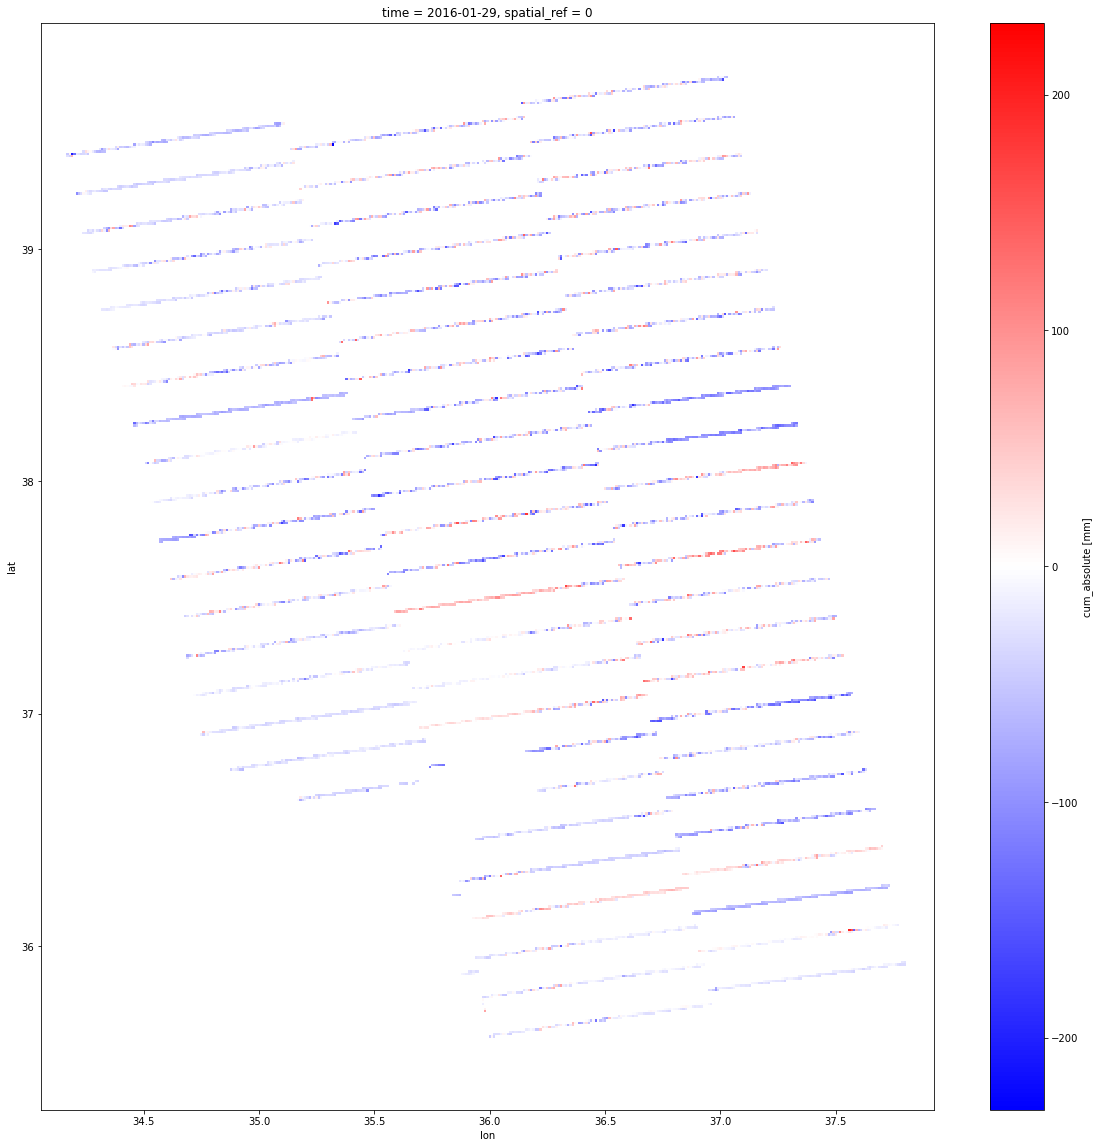

In [10]:
cube['cum_absolute'][1].plot(cmap='bwr', figsize=(20,20))

<AxesSubplot:xlabel='epoch', ylabel='mm'>

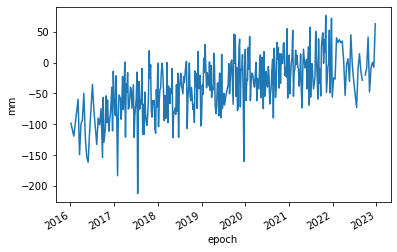

In [11]:
(df_merged.set_index('epoch').daz).plot(ylabel='mm')

In [12]:
cube.cum-cube.daz

<xarray.DataArray (time: 362, lat: 468, lon: 387)>
array([[[ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        ..., 
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan]],

       [[ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        ..., 
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan]],

       [[ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        ..., 
...
        ..., 
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan]],

       [[ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        ..., 
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan]],

       [[ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        ..., 
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan]]])
Coordinates:
  * time         (time) datetime64[ns] 2016-01-05 2016-01-29 ... 2022-12-23
  * lat          (lat) float64 35.3 35.31 35.32 35.33 ... 39.95 39.96 39.97
  * lon          (lon) float64 34.06 34.07 34.08 34.09 ... 37.9 37.91 37.92
    spatial_ref  int64 0
Attributes:
    unit:     mm

In [13]:
df_merged

,epoch,daz
0,2016-01-05,-98.379680
1,2016-01-29,-119.561820
2,2016-02-22,-80.578120
3,2016-03-05,-59.610180
4,2016-03-17,-149.759400
...,...,...
357,2022-11-05,-47.779200
358,2022-11-17,-9.039506
359,2022-11-29,0.335807
360,2022-12-11,-7.650874


In [14]:
dazes

,epoch,daz
1,2014-10-06,-139.67534
77,2014-10-18,-131.32224
78,2015-03-11,-121.71922
79,2015-06-03,-114.66784
80,2015-06-15,-113.76078
...,...,...
271,2024-11-06,28.92078
272,2024-11-18,106.65396
273,2024-12-12,78.05784
274,2024-12-24,72.79776


In [15]:
df_merged_xr

<xarray.Dataset>
Dimensions:  (epoch: 362)
Coordinates:
  * epoch    (epoch) datetime64[ns] 2016-01-05 2016-01-29 ... 2022-12-23
Data variables:
    daz      (epoch) float64 -98.38 -119.6 -80.58 -59.61 ... 0.3358 -7.651 62.95

In [16]:
cube.time

<xarray.DataArray 'time' (time: 362)>
array(['2016-01-05T00:00:00.000000000', '2016-01-29T00:00:00.000000000',
       '2016-02-22T00:00:00.000000000', ..., '2022-11-29T00:00:00.000000000',
       '2022-12-11T00:00:00.000000000', '2022-12-23T00:00:00.000000000'], dtype='datetime64[ns]')
Coordinates:
  * time         (time) datetime64[ns] 2016-01-05 2016-01-29 ... 2022-12-23
    spatial_ref  int64 0

In [17]:
df_merged_xr

<xarray.Dataset>
Dimensions:  (epoch: 362)
Coordinates:
  * epoch    (epoch) datetime64[ns] 2016-01-05 2016-01-29 ... 2022-12-23
Data variables:
    daz      (epoch) float64 -98.38 -119.6 -80.58 -59.61 ... 0.3358 -7.651 62.95

In [18]:
tsadir='/work/scratch-pw2/licsar/mnergiz/new/014A_05232_242525/TS_GEOCml10'
framedir='/work/scratch-pw2/licsar/mnergiz/new/014A_05232_242525'
frame=os.path.basename(framedir)
cumfile=os.path.join(tsadir,'cum.h5')

In [19]:
tsadir='/work/scratch-pw2/licsar/mnergiz/new/014A_05232_242525/TS_GEOCml10'
framedir='/work/scratch-pw2/licsar/mnergiz/new/014A_05232_242525'
frame=os.path.basename(framedir)
cumfile=os.path.join(tsadir,'cum.h5')
cumxr= xr.load_dataset(cumfile)
dazes = dl.get_daz_frame(frame)
dazes=dazes[['epoch', 'daz']]
dazes = dazes.sort_values(by="epoch")
dazes['daz']=dazes['daz']*14000

In [20]:
dazes

,epoch,daz
1,2014-10-06,-139.67534
77,2014-10-18,-131.32224
78,2015-03-11,-121.71922
79,2015-06-03,-114.66784
80,2015-06-15,-113.76078
...,...,...
271,2024-11-06,28.92078
272,2024-11-18,106.65396
273,2024-12-12,78.05784
274,2024-12-24,72.79776


In [21]:
cube.values

<bound method Mapping.values of <xarray.Dataset>
Dimensions:       (time: 362, lat: 468, lon: 387)
Coordinates:
  * time          (time) datetime64[ns] 2016-01-05 2016-01-29 ... 2022-12-23
  * lat           (lat) float64 35.3 35.31 35.32 35.33 ... 39.95 39.96 39.97
  * lon           (lon) float64 34.06 34.07 34.08 34.09 ... 37.9 37.91 37.92
    spatial_ref   int64 0
Data variables:
    cum           (time, lat, lon) float32 nan nan nan nan ... nan nan nan nan
    vel           (lat, lon) float32 nan nan nan nan nan ... nan nan nan nan nan
    iono          (time, lat, lon) float32 nan nan nan nan ... nan nan nan nan
    tide          (time, lat, lon) float32 nan nan nan nan ... nan nan nan nan
    bperp         (time) float32 0.0 99.0 18.0 9.0 ... 26.0 -17.0 12.0 -50.0
    coh           (lat, lon) float32 nan nan nan nan nan ... nan nan nan nan nan
    rms           (lat, lon) float32 nan nan nan nan nan ... nan nan nan nan nan
    vstd          (lat, lon) float32 nan nan nan nan nan .

In [22]:
daz_frame=dl.extract2txt_esds_frame(frame)

In [23]:
dazes

,epoch,daz
1,2014-10-06,-139.67534
77,2014-10-18,-131.32224
78,2015-03-11,-121.71922
79,2015-06-03,-114.66784
80,2015-06-15,-113.76078
...,...,...
271,2024-11-06,28.92078
272,2024-11-18,106.65396
273,2024-12-12,78.05784
274,2024-12-24,72.79776
